# Gesture Recognition - Data Preprocessing

This notebook handles data processing, augmentation, feature extraction, and dataset creation.

**Classes**:
- `grab` - 握拳
- `release` - 释放
- `swipe_up` - 上滑
- `swipe_down` - 下滑
- `noise` - 无效动作

**Notice**: Change the value of CACHE_VERSION after any optimization.

## 1. Environment Setup

In [1]:
# Check GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# Install dependencies
!pip install -q mediapipe onnx onnxruntime scikit-learn tqdm

In [3]:
import os
import json
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
from tqdm import tqdm

from datetime import datetime


def log_info(msg):
    """Print INFO message with timestamp."""
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] INFO - {msg}")


def log_warn(msg):
    """Print WARNING message with timestamp."""
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] WARNING - {msg}")


def log_err(msg):
    """Print ERROR message with timestamp."""
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] ERROR - {msg}")

## 2. Mount Google Drive and Set Dataset Path

In [4]:
# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

# Dataset path
DATASET_PATH = "/content/drive/MyDrive/DSAI5201_Dataset/organized"
TRAIN_DIR = f"{DATASET_PATH}/Train"
TEST_DIR = f"{DATASET_PATH}/Test"

# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

print(f"Dataset path: {DATASET_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/DSAI5201_Dataset/organized


## 3. Constants

In [5]:
# Constants
SEQ_LEN = 30
NUM_LANDMARKS = 21
NUM_COORDS = 3
RAW_DIM = NUM_LANDMARKS * NUM_COORDS
NUM_CLASSES = 5
CACHE_VERSION = "v3_fixed_swipe_reverse"  # Fixed swipe reverse augmentation
MIN_VALID_RATIO = 0.10

# Feature computation constants
WRIST_IDX = 0
MID_FINGER_IDX = 9
FINGERTIP_IDS = [4, 8, 12, 16, 20]
BASE_IDS = [2, 5, 9, 13, 17]
PAIRS = [
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (4, 12),
    (4, 16),
    (4, 20),
    (8, 16),
    (8, 20),
    (12, 20),
]
N_PAIRS = len(PAIRS)
FINGER_CHAINS = [
    [0, 1, 2, 3, 4],
    [0, 5, 6, 7, 8],
    [0, 9, 10, 11, 12],
    [0, 13, 14, 15, 16],
    [0, 17, 18, 19, 20],
]
N_FINGERS = 5
FEATURE_DIM = RAW_DIM + RAW_DIM + 3 + N_PAIRS + N_FINGERS

# Class names
CLASS_NAMES = [
    "grab",  # 握拳
    "release",  # 释放
    "swipe_up",  # 上滑
    "swipe_down",  # 下滑
    "noise",  # 无效动作
]
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
SWIPE_CLASSES = {"swipe_up", "swipe_down"}

print(f"Feature dim: {FEATURE_DIM}")
print(f"Classes: {CLASS_NAMES}")

Feature dim: 144
Classes: ['grab', 'release', 'swipe_up', 'swipe_down', 'noise']


## 4. Preview Video Frames

In [6]:
import matplotlib.pyplot as plt


def preview_video_frames(video_path, num_frames=6, title=None):
    """Preview multiple frames from a video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Cannot open video: {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Sample frames evenly
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()

    # Plot frames
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 3))
    if len(frames) == 1:
        axes = [axes]

    for ax, frame, idx in zip(axes, frames, frame_indices):
        ax.imshow(frame)
        ax.set_title(f"Frame {idx}")
        ax.axis("off")

    if title:
        fig.suptitle(f"{title}\n({total_frames} frames, {fps:.1f} FPS)", fontsize=12)
    plt.tight_layout()
    plt.show()

    return frames

=== Previewing sample videos ===


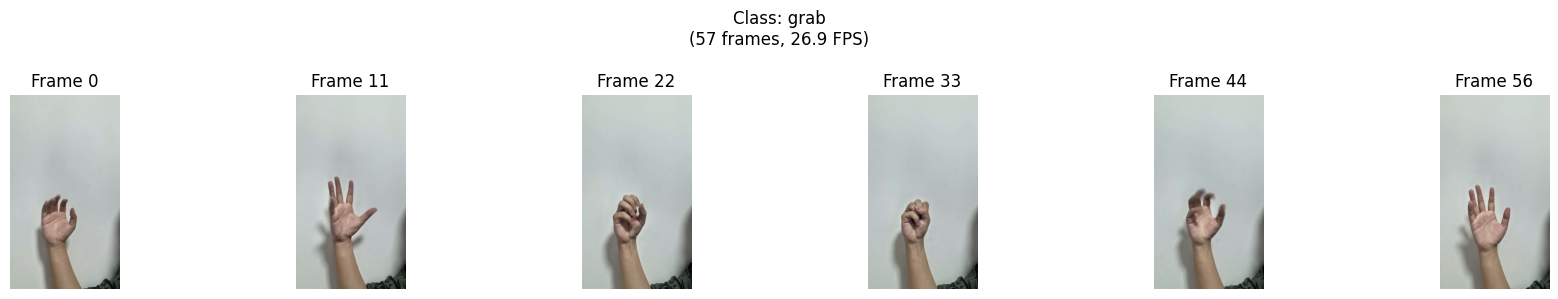

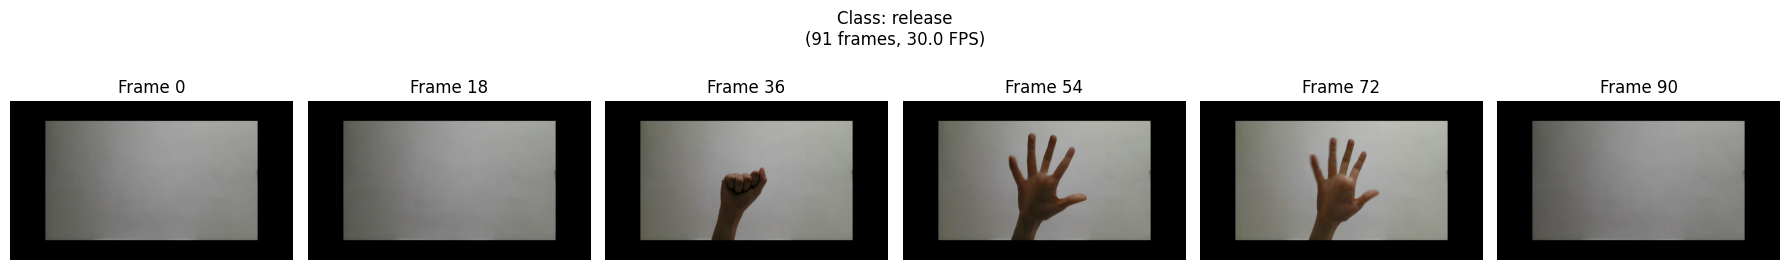

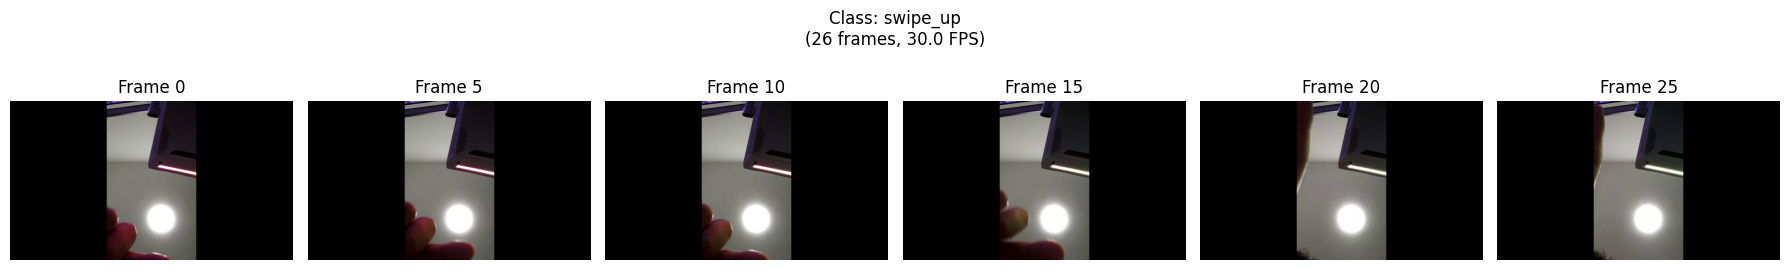

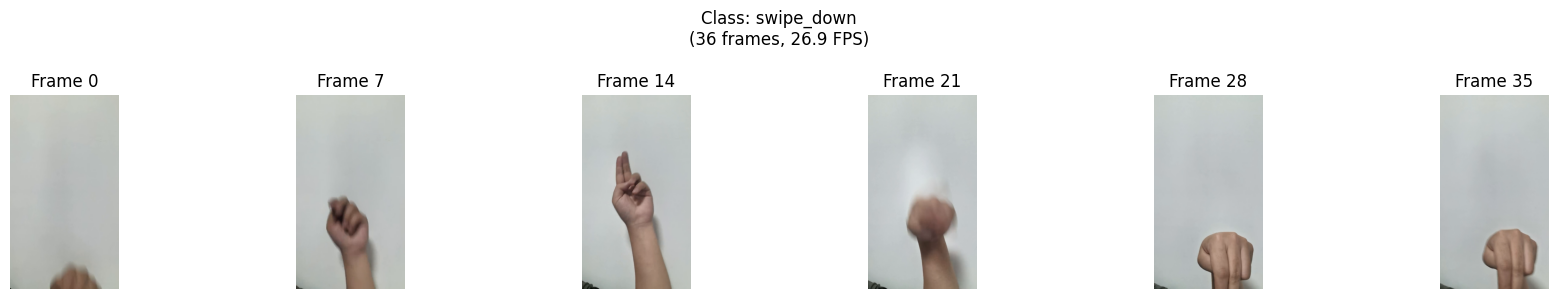

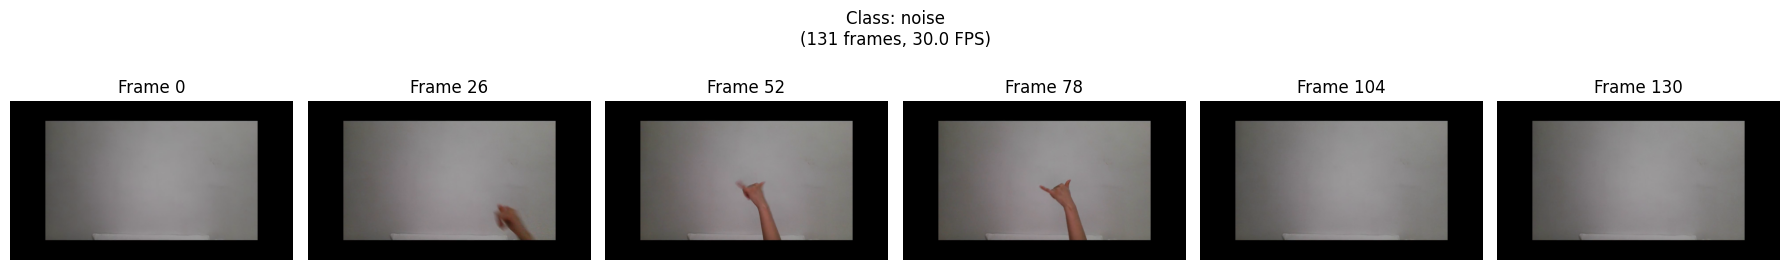

In [7]:
# Preview one video from each class
print("=== Previewing sample videos ===")
for class_name in CLASS_NAMES:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if os.path.exists(class_dir):
        videos = [
            f
            for f in os.listdir(class_dir)
            if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv", ".webm"))
        ]
        if videos:
            video_path = os.path.join(class_dir, videos[0])
            preview_video_frames(video_path, num_frames=6, title=f"Class: {class_name}")

## 5. Hand Landmark Detection (MediaPipe)

In [8]:
# Download MediaPipe hand landmark model
HAND_LANDMARKER_MODEL = "hand_landmarker.task"
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
)


def ensure_model_file(path=HAND_LANDMARKER_MODEL):
    if os.path.exists(path):
        return path
    log_info(f"Downloading {path} ...")
    import requests

    r = requests.get(MODEL_URL, stream=True, timeout=120)
    r.raise_for_status()
    with open(path, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    return path


ensure_model_file()

'hand_landmarker.task'

In [9]:
class HandDetector:
    def __init__(self, static_mode=True, max_hands=1, min_conf=0.5):
        self.api = None
        try:
            import mediapipe as mp
            from mediapipe.tasks import python as mpp
            from mediapipe.tasks.python import vision as mpv

            p = ensure_model_file()
            opts = mpv.HandLandmarkerOptions(
                base_options=mpp.BaseOptions(model_asset_path=p),
                num_hands=max_hands,
                min_hand_detection_confidence=min_conf,
                min_hand_presence_confidence=min_conf,
                min_tracking_confidence=0.5,
            )
            self.detector = mpv.HandLandmarker.create_from_options(opts)
            self.mp = mp
            self.api = "tasks"
            return
        except Exception as e:
            log_warn(f"MediaPipe tasks API failed: {e}")
        try:
            import mediapipe as mp

            self.detector = mp.solutions.hands.Hands(
                static_image_mode=static_mode,
                max_num_hands=max_hands,
                min_detection_confidence=min_conf,
                min_tracking_confidence=0.5,
            )
            self.mp = mp
            self.api = "solutions"
            return
        except Exception as e:
            log_err(f"MediaPipe init failed: {e}")
            raise RuntimeError(f"MediaPipe init failed: {e}")

    def detect(self, frame_bgr):
        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        if self.api == "tasks":
            img = self.mp.Image(image_format=self.mp.ImageFormat.SRGB, data=rgb)
            res = self.detector.detect(img)
            if res.hand_landmarks and len(res.hand_landmarks) > 0:
                c = []
                for lm in res.hand_landmarks[0]:
                    c.extend([lm.x, lm.y, lm.z])
                return np.array(c, dtype=np.float32)
        else:
            res = self.detector.process(rgb)
            if res.multi_hand_landmarks:
                c = []
                for lm in res.multi_hand_landmarks[0].landmark:
                    c.extend([lm.x, lm.y, lm.z])
                return np.array(c, dtype=np.float32)
        return None

    def close(self):
        if hasattr(self.detector, "close"):
            self.detector.close()

## 6. Data Preprocessing Functions

In [10]:
def to_scalar(v, default=None):
    if v is None:
        return default
    if isinstance(v, np.ndarray):
        if v.shape == ():
            v = v.item()
        elif v.size == 1:
            v = v.reshape(()).item()
    if isinstance(v, bytes):
        return v.decode("utf-8")
    return v


def resample(seq, target=SEQ_LEN):
    """Resample sequence to target length using linear interpolation."""
    seq = np.asarray(seq, dtype=np.float32)
    if seq.ndim != 2:
        return np.zeros((target, RAW_DIM), dtype=np.float32)
    n, d = seq.shape
    if n == 0:
        return np.zeros((target, d), dtype=np.float32)
    if n == target:
        return seq.copy()
    x_old = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, target, dtype=np.float32)
    out = np.zeros((target, d), dtype=np.float32)
    for i in range(d):
        out[:, i] = np.interp(x_new, x_old, seq[:, i]).astype(np.float32)
    return out


def to_raw_sequence(seq, target_len=None):
    """Convert various formats to raw sequence (T, RAW_DIM)."""
    try:
        arr = np.asarray(seq, dtype=np.float32)
    except Exception:
        return None
    if arr.size == 0:
        t = 0 if target_len is None else target_len
        return np.zeros((t, RAW_DIM), dtype=np.float32)
    if arr.ndim == 3 and arr.shape[1] == NUM_LANDMARKS and arr.shape[2] == NUM_COORDS:
        arr = arr.reshape(arr.shape[0], RAW_DIM)
    elif arr.ndim == 2 and arr.shape == (NUM_LANDMARKS, NUM_COORDS):
        arr = arr.reshape(1, RAW_DIM)
    elif arr.ndim == 2 and arr.shape[1] == RAW_DIM:
        pass
    elif arr.ndim == 2 and arr.shape[0] == RAW_DIM and arr.shape[1] != RAW_DIM:
        arr = arr.T
        if arr.shape[1] != RAW_DIM:
            return None
    elif arr.ndim == 1 and arr.size % RAW_DIM == 0:
        arr = arr.reshape(-1, RAW_DIM)
    else:
        return None
    arr = np.ascontiguousarray(arr, dtype=np.float32)
    if target_len is not None and arr.shape[0] != target_len:
        arr = resample(arr, target_len)
    return arr

In [11]:
def interp_extrap_1d(valid_idx, valid_vals, n):
    """Interpolate and extrapolate 1D values."""
    xi = np.arange(n, dtype=np.float32)
    xp = np.asarray(valid_idx, dtype=np.float32)
    fp = np.asarray(valid_vals, dtype=np.float32)
    yi = np.interp(xi, xp, fp).astype(np.float32)
    if len(valid_idx) >= 2:
        left = xi < valid_idx[0]
        if left.any():
            dx = float(valid_idx[1] - valid_idx[0])
            slope = 0.0 if dx == 0 else float((fp[1] - fp[0]) / dx)
            yi[left] = fp[0] + (xi[left] - valid_idx[0]) * slope
        right = xi > valid_idx[-1]
        if right.any():
            dx = float(valid_idx[-1] - valid_idx[-2])
            slope = 0.0 if dx == 0 else float((fp[-1] - fp[-2]) / dx)
            yi[right] = fp[-1] + (xi[right] - valid_idx[-1]) * slope
    return yi.astype(np.float32)


def interpolate_missing(lm_list):
    """Interpolate missing landmarks in a sequence."""
    n = len(lm_list)
    if n == 0:
        return np.zeros((0, RAW_DIM), dtype=np.float32)
    valid_idx = [i for i, lm in enumerate(lm_list) if lm is not None]
    if len(valid_idx) == 0:
        return np.zeros((n, RAW_DIM), dtype=np.float32)
    result = np.zeros((n, RAW_DIM), dtype=np.float32)
    valid_arr = []
    for i in valid_idx:
        lm = np.asarray(lm_list[i], dtype=np.float32).reshape(-1)
        if lm.size < RAW_DIM:
            pad = np.zeros((RAW_DIM,), dtype=np.float32)
            pad[: lm.size] = lm
            lm = pad
        elif lm.size > RAW_DIM:
            lm = lm[:RAW_DIM]
        valid_arr.append(lm.astype(np.float32))
        result[i] = lm.astype(np.float32)
    valid_arr = np.stack(valid_arr, axis=0)
    if len(valid_idx) == 1:
        result[:] = valid_arr[0]
        return result
    for d in range(RAW_DIM):
        result[:, d] = interp_extrap_1d(valid_idx, valid_arr[:, d], n)
    return result.astype(np.float32)

In [12]:
def compute_features(raw_seq):
    """Compute feature vector from raw landmark sequence.

    Features include:
    - Normalized landmarks (63 dims)
    - Velocity (63 dims)
    - Wrist velocity (3 dims)
    - Finger distances (10 dims)
    - Finger angles (5 dims)

    Total: 144 dims
    """
    raw_seq = to_raw_sequence(raw_seq)
    if raw_seq is None:
        shape = np.asarray(raw_seq).shape if raw_seq is not None else None
        raise ValueError(f"Invalid raw sequence shape: {shape}")
    T = raw_seq.shape[0]
    if T == 0:
        return np.zeros((0, FEATURE_DIM), dtype=np.float32)
    lms = raw_seq.reshape(T, NUM_LANDMARKS, NUM_COORDS)
    wrist = lms[:, WRIST_IDX, :]
    relative = lms - wrist[:, np.newaxis, :]
    mid = lms[:, MID_FINGER_IDX, :]
    palm_size = np.maximum(np.linalg.norm(mid - wrist, axis=-1, keepdims=True), 1e-6)
    norm_lms = relative / palm_size[:, np.newaxis, :]
    norm_flat = norm_lms.reshape(T, -1).astype(np.float32)
    vel = np.zeros_like(norm_flat)
    if T > 1:
        vel[1:] = norm_flat[1:] - norm_flat[:-1]
        vel[0] = vel[1]
    wrist_vel = np.zeros((T, 3), dtype=np.float32)
    if T > 1:
        wrist_vel[1:] = wrist[1:] - wrist[:-1]
        wrist_vel[0] = wrist_vel[1]
    dists = np.zeros((T, N_PAIRS), dtype=np.float32)
    for k, (i, j) in enumerate(PAIRS):
        dists[:, k] = np.linalg.norm(norm_lms[:, i] - norm_lms[:, j], axis=-1)
    angles = np.zeros((T, N_FINGERS), dtype=np.float32)
    for fi, chain in enumerate(FINGER_CHAINS):
        v1 = lms[:, chain[1]] - lms[:, chain[0]]
        v2 = lms[:, chain[-1]] - lms[:, chain[1]]
        n1 = np.linalg.norm(v1, axis=-1, keepdims=True) + 1e-8
        n2 = np.linalg.norm(v2, axis=-1, keepdims=True) + 1e-8
        cos_a = np.clip((v1 / n1 * v2 / n2).sum(-1), -1.0, 1.0)
        angles[:, fi] = np.arccos(cos_a)
    feat = np.concatenate([norm_flat, vel, wrist_vel, dists, angles], axis=1)
    return feat.astype(np.float32)


# Verify feature dimension
dummy = np.random.randn(SEQ_LEN, RAW_DIM).astype(np.float32)
f = compute_features(dummy)
print(f"Feature dim verified: {f.shape[1]} (expected {FEATURE_DIM})")

Feature dim verified: 144 (expected 144)


## 7. Data Augmentation Functions

In [13]:
def mirror_x(raw_seq):
    """Mirror landmarks along X axis."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for mirror_x")
    s = raw.copy().reshape(-1, NUM_LANDMARKS, NUM_COORDS)
    s[:, :, 0] = 1.0 - s[:, :, 0]
    return s.reshape(-1, RAW_DIM).astype(np.float32)


def rotate_2d(raw_seq, angle_deg):
    """Rotate landmarks around wrist."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for rotate_2d")
    s = raw.copy().reshape(-1, NUM_LANDMARKS, NUM_COORDS)
    wrist = s[:, WRIST_IDX : WRIST_IDX + 1, :2].copy()
    s[:, :, :2] -= wrist
    a = np.radians(angle_deg)
    c, sn = np.cos(a), np.sin(a)
    x = s[:, :, 0].copy()
    y = s[:, :, 1].copy()
    s[:, :, 0] = c * x - sn * y
    s[:, :, 1] = sn * x + c * y
    s[:, :, :2] += wrist
    return s.reshape(-1, RAW_DIM).astype(np.float32)


def scale_landmarks(raw_seq, factor):
    """Scale landmarks around wrist."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for scale_landmarks")
    s = raw.copy().reshape(-1, NUM_LANDMARKS, NUM_COORDS)
    wrist = s[:, WRIST_IDX : WRIST_IDX + 1, :].copy()
    s -= wrist
    s *= factor
    s += wrist
    return s.reshape(-1, RAW_DIM).astype(np.float32)


def add_jitter(raw_seq, sigma=0.003):
    """Add Gaussian noise to landmarks."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for add_jitter")
    noise = np.random.randn(*raw.shape).astype(np.float32) * sigma
    return (raw + noise).astype(np.float32)


def time_warp(raw_seq):
    """Apply time warping augmentation."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for time_warp")
    n = len(raw)
    if n < 4:
        return raw.copy()
    anchor = np.random.uniform(0.3, 0.7)
    warp = np.random.uniform(0.8, 1.2)
    x = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.where(
        x < anchor,
        x * warp,
        anchor * warp + (x - anchor) * (1.0 - anchor * warp) / (1.0 - anchor + 1e-8),
    )
    x_new = np.clip(x_new, 0.0, 1.0)
    out = np.zeros_like(raw)
    x_target = np.linspace(0.0, 1.0, n, dtype=np.float32)
    for d in range(raw.shape[1]):
        out[:, d] = np.interp(x_target, x_new, raw[:, d]).astype(np.float32)
    return out.astype(np.float32)


def speed_change(raw_seq):
    """Change speed of sequence."""
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for speed_change")
    n = len(raw)
    factor = np.random.uniform(0.8, 1.2)
    new_n = max(int(n * factor), SEQ_LEN // 2)
    x_old = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, new_n, dtype=np.float32)
    out = np.zeros((new_n, raw.shape[1]), dtype=np.float32)
    for d in range(raw.shape[1]):
        out[:, d] = np.interp(x_new, x_old, raw[:, d]).astype(np.float32)
    return out.astype(np.float32)

## 8. Video Processing and Sample Generation

In [14]:
def extract_video(video_path, detector):
    """Extract hand landmarks from video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], 0
    lms = []
    total = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        total += 1
        lms.append(detector.detect(frame))
    cap.release()
    return lms, total


def make_samples(lm_list, total_frames, class_name, is_train):
    """Generate training samples from landmark list."""
    valid = sum(1 for lm in lm_list if lm is not None)
    if total_frames == 0 or valid / total_frames < MIN_VALID_RATIO:
        return [], []
    raw = interpolate_missing(lm_list)
    n = len(raw)
    label = CLASS_TO_IDX[class_name]
    samples = []
    labels = []

    # Base sample
    base = resample(raw, SEQ_LEN)
    samples.append(base.astype(np.float32))
    labels.append(label)

    if not is_train:
        return samples, labels

    # Time-based cropping for longer sequences
    if n > SEQ_LEN:
        for start_r in [0.0, 0.15, 0.25]:
            for end_r in [0.75, 0.85, 1.0]:
                s = int(n * start_r)
                e = int(n * end_r)
                if e - s >= SEQ_LEN // 2:
                    sub = resample(raw[s:e], SEQ_LEN)
                    samples.append(sub.astype(np.float32))
                    labels.append(label)

    # Jitter augmentation
    for _ in range(3):
        aug = add_jitter(raw.copy())
        aug = resample(aug, SEQ_LEN)
        samples.append(aug.astype(np.float32))
        labels.append(label)

    # Rotation augmentation
    for angle in [-15, -10, -5, 5, 10, 15]:
        rot = rotate_2d(raw.copy(), angle)
        rot = resample(rot, SEQ_LEN)
        samples.append(rot.astype(np.float32))
        labels.append(label)

    # Scale augmentation
    for sc in [0.85, 0.9, 1.1, 1.15]:
        scaled = scale_landmarks(raw.copy(), sc)
        scaled = resample(scaled, SEQ_LEN)
        samples.append(scaled.astype(np.float32))
        labels.append(label)

    # Time warp augmentation
    for _ in range(2):
        tw = time_warp(raw.copy())
        tw = resample(tw, SEQ_LEN)
        samples.append(tw.astype(np.float32))
        labels.append(label)

    # Speed change augmentation
    for _ in range(2):
        sp = speed_change(raw.copy())
        sp = resample(sp, SEQ_LEN)
        samples.append(sp.astype(np.float32))
        labels.append(label)

    # Mirror (only for non-swipe gestures, label unchanged)
    if class_name not in SWIPE_CLASSES:
        mir = mirror_x(raw.copy())
        mir = resample(mir, SEQ_LEN)
        samples.append(mir.astype(np.float32))
        labels.append(label)

    # Reverse time augmentation
    # grab (PALM -> FIST) reversed = release (FIST -> PALM)
    # release (FIST -> PALM) reversed = grab (PALM -> FIST)
    # swipe_up reversed = swipe_down (direction flips)
    # swipe_down reversed = swipe_up (direction flips)
    # noise reversed = noise (unchanged)
    rev = raw[::-1].copy()
    rev = resample(rev, SEQ_LEN)
    samples.append(rev.astype(np.float32))

    if class_name == "grab":
        labels.append(CLASS_TO_IDX["release"])
    elif class_name == "release":
        labels.append(CLASS_TO_IDX["grab"])
    elif class_name == "swipe_up":
        labels.append(CLASS_TO_IDX["swipe_down"])
    elif class_name == "swipe_down":
        labels.append(CLASS_TO_IDX["swipe_up"])
    else:
        # noise - label unchanged
        labels.append(label)

    return samples, labels

## 9. Dataset Loading with Cache

In [15]:
def save_cache(cache_path, samples, labels, is_train):
    try:
        os.makedirs(os.path.dirname(os.path.abspath(cache_path)), exist_ok=True)
        if len(samples) == 0:
            sample_arr = np.zeros((0, SEQ_LEN, RAW_DIM), dtype=np.float32)
        else:
            sample_arr = np.stack(
                [to_raw_sequence(s, target_len=SEQ_LEN) for s in samples], axis=0
            ).astype(np.float32)
        label_arr = np.asarray(labels, dtype=np.int64)
        np.savez_compressed(
            cache_path,
            cache_version=np.array(CACHE_VERSION),
            sample_format=np.array("raw_landmarks"),
            raw_dim=np.array(RAW_DIM),
            seq_len=np.array(SEQ_LEN),
            is_train=np.array(int(is_train)),
            samples=sample_arr,
            labels=label_arr,
        )
        log_info(f"Cache saved: {cache_path}")
    except Exception as e:
        log_warn(f"Failed to save cache {cache_path}: {e}")


def try_load_cache(cache_path, is_train):
    if not cache_path or not os.path.exists(cache_path):
        return None
    log_info(f"Loading cache: {cache_path}")
    try:
        with np.load(cache_path, allow_pickle=True) as c:
            version = (
                to_scalar(c["cache_version"]) if "cache_version" in c.files else None
            )
            sample_format = (
                to_scalar(c["sample_format"]) if "sample_format" in c.files else None
            )
            raw_dim = to_scalar(c["raw_dim"]) if "raw_dim" in c.files else None
            seq_len = to_scalar(c["seq_len"]) if "seq_len" in c.files else None
            cache_is_train = to_scalar(c["is_train"]) if "is_train" in c.files else None
            if (
                version != CACHE_VERSION
                or sample_format != "raw_landmarks"
                or raw_dim != RAW_DIM
                or seq_len != SEQ_LEN
                or cache_is_train != int(is_train)
            ):
                raise ValueError("cache metadata mismatch")
            samples = np.asarray(c["samples"], dtype=np.float32)
            labels = np.asarray(c["labels"], dtype=np.int64)
        if (
            samples.ndim != 3
            or samples.shape[1] != SEQ_LEN
            or samples.shape[2] != RAW_DIM
        ):
            raise ValueError(f"cache sample shape mismatch: {samples.shape}")
        if len(samples) != len(labels):
            raise ValueError("cache sample/label count mismatch")
        out_samples = [np.ascontiguousarray(s, dtype=np.float32) for s in samples]
        out_labels = labels.astype(np.int64).tolist()
        log_info(f"  {len(out_samples)} samples loaded")
        return out_samples, out_labels
    except Exception as e:
        log_warn(f"Cache incompatible, rebuilding from videos: {e}")
        return None


def sanitize_dataset(samples, labels, name):
    fixed_samples = []
    fixed_labels = []
    if len(samples) != len(labels):
        log_warn(f"{name}: sample/label count mismatch, using min length")
    for s, l in zip(samples, labels):
        raw = to_raw_sequence(s, target_len=SEQ_LEN)
        if raw is None:
            continue
        fixed_samples.append(raw.astype(np.float32))
        fixed_labels.append(int(l))
    skipped = len(list(zip(samples, labels))) - len(fixed_samples)
    if skipped > 0:
        log_warn(f"{name}: skipped {skipped} invalid samples")
    return fixed_samples, fixed_labels

In [16]:
def load_dataset(data_dir, detector, cache_path=None, is_train=True):
    cached = try_load_cache(cache_path, is_train)
    if cached is not None:
        return cached

    all_samples, all_labels = [], []
    counts = defaultdict(int)
    dp = Path(data_dir)
    for cn in CLASS_NAMES:
        cd = dp / cn
        if not cd.exists():
            log_warn(f"Not found: {cd}")
            continue
        vfs = sorted(
            f
            for f in cd.iterdir()
            if f.suffix.lower() in (".mp4", ".avi", ".mov", ".mkv", ".webm")
        )
        log_info(f"  [{cn}]: {len(vfs)} videos")
        for vf in tqdm(vfs, desc=f"  {cn}", leave=False):
            lm_list, total = extract_video(vf, detector)
            if total == 0:
                continue
            samps, labs = make_samples(lm_list, total, cn, is_train)
            for s, l in zip(samps, labs):
                raw = to_raw_sequence(s, target_len=SEQ_LEN)
                if raw is None:
                    continue
                all_samples.append(raw.astype(np.float32))
                all_labels.append(int(l))
                counts[CLASS_NAMES[l]] += 1

    log_info("Dataset statistics:")
    for cn in CLASS_NAMES:
        log_info(f"  {cn:>15s}: {counts[cn]:>5d} samples")
    log_info(f"  {'Total':>15s}: {len(all_samples):>5d} samples")

    if cache_path:
        save_cache(cache_path, all_samples, all_labels, is_train)

    return all_samples, all_labels

## 10. Load and Process Datasets

In [17]:
# Load datasets
detector = HandDetector(static_mode=True, max_hands=1, min_conf=0.5)

cache_dir = "checkpoints/cache"
tr_cache = os.path.join(cache_dir, f"train_{CACHE_VERSION}.npz")
te_cache = os.path.join(cache_dir, f"test_{CACHE_VERSION}.npz")

log_info("[Phase 1] Extracting landmarks ...")
train_samples, train_labels = load_dataset(TRAIN_DIR, detector, tr_cache, is_train=True)
test_samples, test_labels = load_dataset(TEST_DIR, detector, te_cache, is_train=False)
detector.close()

train_samples, train_labels = sanitize_dataset(train_samples, train_labels, "train")
test_samples, test_labels = sanitize_dataset(test_samples, test_labels, "test")

print(f"\nTrain samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")

[00:25:02] INFO - [Phase 1] Extracting landmarks ...
[00:25:02] INFO -   [grab]: 24 videos


[00:26:11] INFO -   [release]: 24 videos


[00:27:12] INFO -   [swipe_up]: 24 videos


[00:28:08] INFO -   [swipe_down]: 24 videos


[00:29:03] INFO -   [noise]: 31 videos


...

[00:31:00] INFO -   [release]: 6 videos


[00:31:15] INFO -   [swipe_up]: 6 videos


[00:31:29] INFO -   [swipe_down]: 6 videos


[00:31:43] INFO -   [noise]: 9 videos


[00:32:08] INFO - Dataset statistics:
[00:32:08] INFO -              grab:     6 samples
[00:32:08] INFO -           release:     6 samples
[00:32:08] INFO -          swipe_up:     5 samples
[00:32:08] INFO -        swipe_down:     5 samples
[00:32:08] INFO -             noise:     7 samples
[00:32:08] INFO -             Total:    29 samples
[00:32:08] INFO - Cache saved: checkpoints/cache/test_v3_fixed_swipe_reverse.npz

Train samples: 3018
Test samples: 29


## 11. Normalization Statistics

In [18]:
def compute_norm_stats(samples):
    sum_feat = None
    sum_sq_feat = None
    total_frames = 0
    bad = 0

    for s in tqdm(samples, desc="Computing stats", leave=False):
        raw = to_raw_sequence(s, target_len=SEQ_LEN)
        if raw is None:
            bad += 1
            continue
        feat = compute_features(raw).astype(np.float64)
        cur_sum = feat.sum(axis=0)
        cur_sq = np.square(feat).sum(axis=0)
        if sum_feat is None:
            sum_feat = cur_sum
            sum_sq_feat = cur_sq
        else:
            sum_feat += cur_sum
            sum_sq_feat += cur_sq
        total_frames += feat.shape[0]

    if total_frames == 0:
        raise RuntimeError("No valid samples for normalization")

    mean64 = sum_feat / total_frames
    var64 = np.maximum(sum_sq_feat / total_frames - np.square(mean64), 1e-12)
    mean = mean64.astype(np.float32)
    std = np.sqrt(var64).astype(np.float32)

    if bad > 0:
        log_warn(f"Skipped {bad} invalid samples while computing normalization stats")

    return {"mean": mean, "std": std}


log_info("[Phase 2] Computing normalization stats ...")
norm_stats = compute_norm_stats(train_samples)
print(f"Mean range: [{norm_stats['mean'].min():.4f}, {norm_stats['mean'].max():.4f}]")
print(f"Std range:  [{norm_stats['std'].min():.4f}, {norm_stats['std'].max():.4f}]")

[00:32:08] INFO - [Phase 2] Computing normalization stats ...


Computing stats:   0%|          | 0/3018 [00:00<?, ?it/s]

Mean range: [-0.8790, 1.6512]
Std range:  [0.0000, 1.1413]


## 12. Save Preprocessed Data

In [19]:
import torch

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

# Save normalization stats
norm_path = os.path.join(save_dir, "norm_stats.pt")
torch.save(norm_stats, norm_path)
log_info(f"Saved norm_stats to {norm_path}")

# Save dataset info
dataset_info = {
    "train_samples": len(train_samples),
    "test_samples": len(test_samples),
    "class_names": CLASS_NAMES,
    "cache_version": CACHE_VERSION,
    "seq_len": SEQ_LEN,
    "feature_dim": FEATURE_DIM,
    "raw_dim": RAW_DIM,
    "num_classes": NUM_CLASSES,
    "pairs": PAIRS,
    "fingertip_ids": FINGERTIP_IDS,
    "base_ids": BASE_IDS,
    "n_fingers": N_FINGERS,
    "finger_chains": FINGER_CHAINS,
}

info_path = os.path.join(save_dir, "dataset_info.json")
with open(info_path, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, ensure_ascii=False)
log_info(f"Saved dataset_info to {info_path}")

# Save class distribution
train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
test_counts = np.bincount(test_labels, minlength=NUM_CLASSES)
print("\nClass distribution:")
for i, cn in enumerate(CLASS_NAMES):
    print(f"  {cn:>12s}: train={train_counts[i]:>4d}, test={test_counts[i]:>3d}")

[00:32:12] INFO - Saved norm_stats to checkpoints/norm_stats.pt
[00:32:12] INFO - Saved dataset_info to checkpoints/dataset_info.json

Class distribution:
          grab: train= 612, test=  6
       release: train= 684, test=  6
      swipe_up: train= 471, test=  5
    swipe_down: train= 584, test=  5
         noise: train= 667, test=  7


In [20]:
# 复制到 Google Drive
import shutil

drive_path = "/content/drive/MyDrive/checkpoints"
shutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)
print(f"文件已复制到: {drive_path}")

文件已复制到: /content/drive/MyDrive/checkpoints


## Summary

This notebook has:
1. Previewed sample videos from each class
2. Extracted hand landmarks using MediaPipe
3. Applied data augmentation for training data
4. Computed normalization statistics
5. Saved preprocessed data for training

**Output files:**
- `checkpoints/cache/train_{CACHE_VERSION}_raw.npz` - Training data cache
- `checkpoints/cache/test_{CACHE_VERSION}_raw.npz` - Test data cache
- `checkpoints/norm_stats.pt` - Normalization statistics
- `checkpoints/dataset_info.json` - Dataset metadata